In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist

In [3]:
np.random.seed(42)

In [ ]:
sample_size = 5000
corr = np.array([[1, 0.7], [0.7, 1]])
stdev = np.array([5, 4])
mean = [0, 0]

In [5]:
def corr2cov(corr, stdev):
    return np.outer(stdev, stdev) * corr

cov = corr2cov(corr, stdev)
x = np.random.multivariate_normal(mean, cov, sample_size)
data = pd.DataFrame(x, columns=["x0", "x1"])

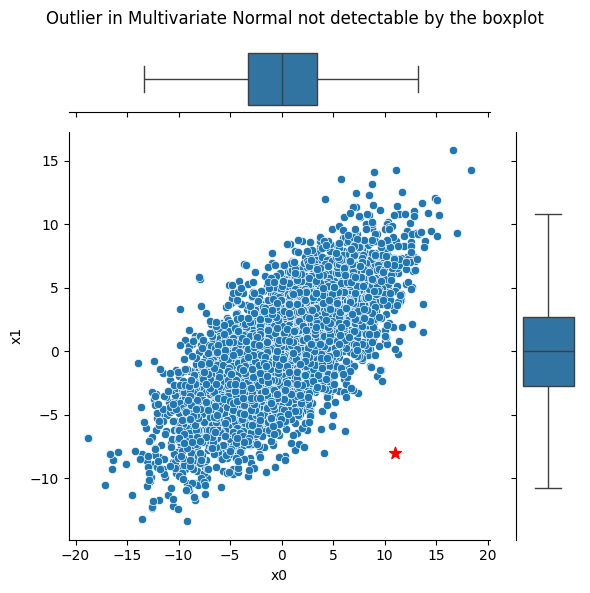

In [ ]:
outlier = pd.DataFrame([[11, -8]], columns=["x0", "x1"])

g = sns.JointGrid(data=data, x="x0", y="x1")
g = g.plot_joint(sns.scatterplot)
g = g.plot_marginals(sns.boxplot, showfliers=False)
g.ax_joint.scatter(outlier["x0"], outlier["x1"], color="red", marker="*", s=80)
g.fig.suptitle("Outlier in Multivariate Normal not detectable by the boxplot")
g.fig.tight_layout()
plt.savefig("img/boxplot-chart.png")
plt.show()

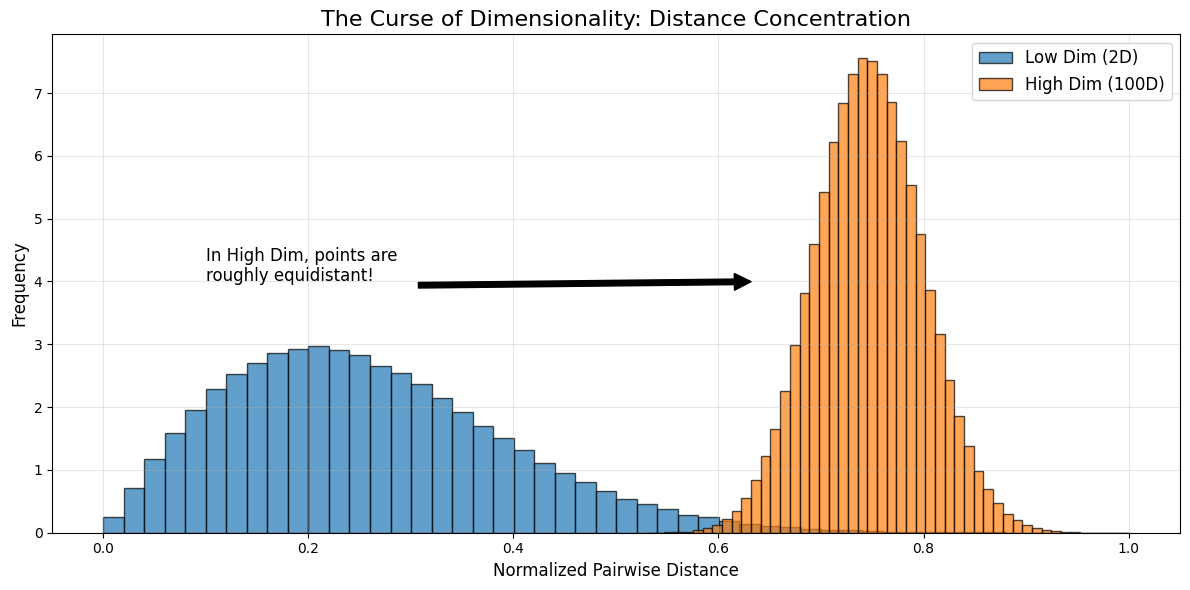

In [ ]:
n_samples = 1000
X_low = np.random.normal(0, 1, (n_samples, 2)) # 2D
X_high = np.random.normal(0, 1, (n_samples, 100)) # 100D

# Pairwise Distances (Euclidean)
dist_low = pdist(X_low, "euclidean")
dist_high = pdist(X_high, "euclidean")

# Normalizing distances to fit on the same x-axis scale (0 to 1) for comparison
dist_low_norm = dist_low / np.max(dist_low)
dist_high_norm = dist_high / np.max(dist_high)

plt.figure(figsize=(12, 6))
plt.hist(dist_low_norm, bins=50, alpha=0.7, label="Low Dim (2D)", density=True, color="#1f77b4", edgecolor="black")
plt.hist(dist_high_norm, bins=50, alpha=0.7, label="High Dim (100D)", density=True, color="#ff7f0e", edgecolor="black")

plt.title("The Curse of Dimensionality: Distance Concentration", fontsize=16)
plt.xlabel("Normalized Pairwise Distance", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.annotate("In High Dim, points are\nroughly equidistant!", 
             xy=(0.65, 4), xytext=(0.1, 4),
             arrowprops=dict(facecolor="black", shrink=0.05),
             fontsize=12)

plt.tight_layout()
plt.savefig("img/dim-chart.png")
plt.show()